# FIFA World Cup 2026: Data Cleaning and Exploration

This notebook performs end-to-end data cleaning and basic exploratory
analysis on the FIFA World Cup 2026 dataset. The dataset covers 1,248
players across all 48 participating nations, sourced from Kaggle and
GitHub (CC0 license).

**Dataset source:** https://www.kaggle.com/datasets/mominullptr/fifa-world-cup-2026-dataset

The workflow follows a standard data preparation pipeline:
1. Load raw data
2. Inspect structure, types, and quality
3. Handle missing values, duplicates, and type issues
4. Compute summary statistics
5. Produce visualizations

## 1. Environment Setup

Install required packages if running for the first time.

In [1]:
# Uncomment and run the line below if packages are not installed.
# !pip install pandas matplotlib seaborn

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Data Loading

Download three CSV files directly from the GitHub repository using
pandas. The raw files are hosted at known URLs, so no API key is needed.

In [3]:
BASE_URL = (
    'https://raw.githubusercontent.com/'
    'mominullptr/FIFA-World-Cup-2026-Dataset/main/'
)

FILES = {
    'players': 'squads_and_players.csv',
    'stats':   'player_stats.csv',
    'teams':   'teams.csv',
}

datasets = {}
for key, filename in FILES.items():
    url = BASE_URL + filename
    datasets[key] = pd.read_csv(url)
    print(f'Loaded {filename}: {datasets[key].shape[0]} rows, {datasets[key].shape[1]} columns')

players = datasets['players']
stats   = datasets['stats']
teams   = datasets['teams']

Loaded squads_and_players.csv: 1248 rows, 10 columns


Loaded player_stats.csv: 1248 rows, 21 columns
Loaded teams.csv: 48 rows, 8 columns


## 3. Initial Exploration

Before cleaning, we inspect each DataFrame to understand column names,
data types, and a sample of the rows.

In [4]:
print('=== players ===')
players.head(10)

=== players ===


,player_id,team_id,player_name,position,club_team,market_value_eur,caps,date_of_birth,height_cm,goals
0,1,1,José Raúl Rangel,GK,CD Guadalajara,6500000,15,2000-02-25,190,0
1,2,1,Jorge Eduardo Sanchez,DEF,PAOK Saloniki,2000000,59,1997-12-10,176,3
2,3,1,César Jasib Montes,DEF,FC Lokomotiv Moscow,7500000,69,1997-02-24,191,4
3,4,1,Edson Omar Alvarez,DEF,Fenerbahçe SK,15000000,100,1997-10-24,180,7
4,5,1,Johan Felipe Vasquez,DEF,Genoa CFC,12000000,47,1998-10-22,182,3
5,6,1,Erik Antonio Lira,MID,CF Cruz Azul,12000000,26,2000-05-08,172,0
6,7,1,Luis Francisco Romo,MID,CD Guadalajara,3000000,62,1995-06-05,183,4
7,8,1,Álvaro Fidalgo,MID,Real Betis,6000000,5,1997-04-09,175,0
8,9,1,Raúl Alonso Jimenez,FWD,Fulham FC,3000000,127,1991-05-05,188,46
9,10,1,Ernesto Alexis Vega,FWD,Deportivo Toluca FC,8000000,53,1997-11-25,175,7


In [5]:
players.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1248 entries, 0 to 1247
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   player_id         1248 non-null   int64 
 1   team_id           1248 non-null   int64 
 2   player_name       1248 non-null   object
 3   position          1248 non-null   object
 4   club_team         1248 non-null   object
 5   market_value_eur  1248 non-null   int64 
 6   caps              1248 non-null   int64 
 7   date_of_birth     1248 non-null   object
 8   height_cm         1248 non-null   int64 
 9   goals             1248 non-null   int64 
dtypes: int64(6), object(4)
memory usage: 97.6+ KB


In [6]:
print('=== stats ===')
stats.head(10)

=== stats ===


,player_id,player_name,team_id,position,matches_played,matches_started,minutes_played,goals,assists,shots,shots_on_target,yellow_cards,red_cards,penalty_goals,own_goals,clean_sheets,saves,goals_conceded,average_rating,data_source,last_verified
0,1,José Raúl Rangel,1,GK,4,4,348,0,0,NaN,NaN,0,0,0,0,4.0,5.0,0.0,NaN,sofascore.com,2026-07-01
1,2,Jorge Eduardo Sanchez,1,DEF,3,3,270,0,1,NaN,NaN,0,0,0,0,NaN,NaN,NaN,NaN,sofascore.com,2026-07-01
2,3,César Jasib Montes,1,DEF,3,3,270,0,0,NaN,NaN,0,1,0,0,NaN,NaN,NaN,NaN,sofascore.com,2026-07-01
3,4,Edson Omar Alvarez,1,DEF,3,2,194,0,0,NaN,NaN,1,0,0,0,NaN,NaN,NaN,NaN,sofascore.com,2026-07-01
4,5,Johan Felipe Vasquez,1,DEF,3,3,270,0,0,NaN,NaN,0,0,0,0,NaN,NaN,NaN,NaN,sofascore.com,2026-07-01
5,6,Erik Antonio Lira,1,MID,3,3,256,0,1,NaN,NaN,0,0,0,0,NaN,NaN,NaN,NaN,sofascore.com,2026-07-01
6,7,Luis Francisco Romo,1,MID,3,3,207,1,1,NaN,NaN,0,0,0,0,NaN,NaN,NaN,NaN,sofascore.com,2026-07-01
7,8,Álvaro Fidalgo,1,MID,2,1,84,1,0,NaN,NaN,0,0,0,0,NaN,NaN,NaN,NaN,sofascore.com,2026-07-01
8,9,Raúl Alonso Jimenez,1,FWD,3,3,229,2,0,NaN,NaN,0,0,0,0,NaN,NaN,NaN,NaN,sofascore.com,2026-07-01
9,10,Ernesto Alexis Vega,1,FWD,1,0,11,0,0,NaN,NaN,0,0,0,0,NaN,NaN,NaN,NaN,sofascore.com,2026-07-01


In [7]:
stats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1248 entries, 0 to 1247
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   player_id        1248 non-null   int64  
 1   player_name      1248 non-null   object 
 2   team_id          1248 non-null   int64  
 3   position         1248 non-null   object 
 4   matches_played   1248 non-null   int64  
 5   matches_started  1248 non-null   int64  
 6   minutes_played   1248 non-null   int64  
 7   goals            1248 non-null   int64  
 8   assists          1248 non-null   int64  
 9   shots            0 non-null      float64
 10  shots_on_target  0 non-null      float64
 11  yellow_cards     1248 non-null   int64  
 12  red_cards        1248 non-null   int64  
 13  penalty_goals    1248 non-null   int64  
 14  own_goals        1248 non-null   int64  
 15  clean_sheets     145 non-null    float64
 16  saves            145 non-null    float64
 17  goals_conceded

In [8]:
print('=== teams ===')
teams.head(10)

=== teams ===


,team_id,team_name,fifa_code,group_letter,confederation,fifa_ranking_pre_tournament,elo_rating,manager_name
0,1,Mexico,MEX,A,CONCACAF,14,1810,Javier Aguirre
1,2,South Africa,RSA,A,CAF,60,1620,Hugo Broos
2,3,South Korea,KOR,A,AFC,22,1800,Hong Myung-bo
3,4,Czechia,CZE,A,UEFA,40,1740,Miroslav Koubek
4,5,Canada,CAN,B,CONCACAF,33,1795,Jesse Marsch
5,6,Bosnia and Herzegovina,BIH,B,UEFA,64,1645,Sergej Barbarez
6,7,Qatar,QAT,B,AFC,56,1600,Julen Lopetegui
7,8,Switzerland,SUI,B,UEFA,19,1860,Murat Yakin
8,9,Brazil,BRA,C,CONMEBOL,6,2030,Carlo Ancelotti
9,10,Morocco,MAR,C,CAF,7,1920,Walid Regragui


## 4. Data Quality Assessment

Identify missing values, duplicate rows, and data type mismatches.

### 4.1 Missing Values

In [9]:
def report_missing(df: pd.DataFrame, label: str) -> None:
    """Print a summary of missing values for each column."""
    missing = df.isnull().sum()
    total   = missing.sum()
    print(f'{label}: {total} total missing values across {(missing > 0).sum()} columns')
    if total > 0:
        print(missing[missing > 0].sort_values(ascending=False))
    print()

report_missing(players, 'players')
report_missing(stats,   'stats')
report_missing(teams,   'teams')

players: 0 total missing values across 0 columns



stats: 7279 total missing values across 7 columns
shots              1248
shots_on_target    1248
average_rating     1248
clean_sheets       1103
saves              1103
goals_conceded     1103
data_source         226
dtype: int64

teams: 0 total missing values across 0 columns



### 4.2 Duplicate Rows

In [10]:
for label, df in [('players', players), ('stats', stats), ('teams', teams)]:
    dup_count = df.duplicated().sum()
    print(f'{label}: {dup_count} duplicate rows')

players: 0 duplicate rows
stats: 0 duplicate rows
teams: 0 duplicate rows


### 4.3 Data Types

In [11]:
print('--- players dtypes ---')
print(players.dtypes)
print()
print('--- stats dtypes ---')
print(stats.dtypes)

--- players dtypes ---
player_id            int64
team_id              int64
player_name         object
position            object
club_team           object
market_value_eur     int64
caps                 int64
date_of_birth       object
height_cm            int64
goals                int64
dtype: object

--- stats dtypes ---
player_id            int64
player_name         object
team_id              int64
position            object
matches_played       int64
matches_started      int64
minutes_played       int64
goals                int64
assists              int64
shots              float64
shots_on_target    float64
yellow_cards         int64
red_cards            int64
penalty_goals        int64
own_goals            int64
clean_sheets       float64
saves              float64
goals_conceded     float64
average_rating     float64
data_source         object
last_verified       object
dtype: object


## 5. Data Cleaning

Cleaning strategy:
- **Missing club_team**: Fill with 'Unknown' (player still registered)
- **Missing numeric stats**: Fill goalkeeper columns with 0 for outfield
  players (these are not applicable, not truly missing)
- **date_of_birth**: Convert from string to datetime
- **Duplicates**: Drop exact duplicate rows
- **Zero-play players**: Keep them; they are valid squad members

### 5.1 Handle Missing Values in Players

In [12]:
# club_team: fill missing with 'Unknown'
players['club_team'] = players['club_team'].fillna('Unknown')

# market_value_eur: fill missing with median (robust to outliers)
median_value = players['market_value_eur'].median()
players['market_value_eur'] = players['market_value_eur'].fillna(median_value)

# height_cm: fill missing with median
median_height = players['height_cm'].median()
players['height_cm'] = players['height_cm'].fillna(median_height)

# goals: fill missing with 0 (no goals recorded)
players['goals'] = players['goals'].fillna(0)

print('Players missing values after cleaning:')
print(players.isnull().sum())

Players missing values after cleaning:
player_id           0
team_id             0
player_name         0
position            0
club_team           0
market_value_eur    0
caps                0
date_of_birth       0
height_cm           0
goals               0
dtype: int64


### 5.2 Fix Date Type in Players

In [13]:
players['date_of_birth'] = pd.to_datetime(
    players['date_of_birth'], errors='coerce'
)

# Derive age from date of birth (as of tournament date: July 2026)
tournament_date = pd.Timestamp('2026-07-01')
players['age'] = ((tournament_date - players['date_of_birth']).dt.days / 365.25).round(1)

print(f'date_of_birth dtype: {players["date_of_birth"].dtype}')
print(f'Rows with invalid DOB: {players["date_of_birth"].isnull().sum()}')

date_of_birth dtype: datetime64[ns]
Rows with invalid DOB: 0


### 5.3 Handle Missing Values in Player Stats

In [14]:
# Goalkeeper-specific columns: saves, goals_conceded, clean_sheets
# These are NULL for outfield players by design, not actual missing data.
# Fill with 0 for consistency.

gk_cols = ['saves', 'goals_conceded', 'clean_sheets']
stats[gk_cols] = stats[gk_cols].fillna(0)

# Outfield columns that may be NULL for players who did not play
outfield_cols = ['shots', 'shots_on_target', 'average_rating']
stats[outfield_cols] = stats[outfield_cols].fillna(0)

# last_verified: fill missing with a default
stats['last_verified'] = stats['last_verified'].fillna('unknown')

print('Stats missing values after cleaning:')
print(stats.isnull().sum())

Stats missing values after cleaning:
player_id            0
player_name          0
team_id              0
position             0
matches_played       0
matches_started      0
minutes_played       0
goals                0
assists              0
shots                0
shots_on_target      0
yellow_cards         0
red_cards            0
penalty_goals        0
own_goals            0
clean_sheets         0
saves                0
goals_conceded       0
average_rating       0
data_source        226
last_verified        0
dtype: int64


### 5.4 Remove Duplicates

In [15]:
before_p = len(players)
before_s = len(stats)

players.drop_duplicates(inplace=True)
stats.drop_duplicates(inplace=True)

print(f'players: {before_p} -> {len(players)} rows ({before_p - len(players)} removed)')
print(f'stats:   {before_s} -> {len(stats)} rows ({before_s - len(stats)} removed)')

players: 1248 -> 1248 rows (0 removed)


stats:   1248 -> 1248 rows (0 removed)


### 5.5 Merge Players and Stats

In [16]:
# Merge on player_id to create a unified analysis dataset.
# Drop overlapping columns from stats that are already in players.
# Rename stats.goals -> tournament_goals to avoid conflict with players.goals (international goals).
stats_for_merge = stats.drop(
    columns=['team_id', 'player_name', 'position'], errors='ignore'
).rename(columns={'goals': 'tournament_goals'})

merged = pd.merge(
    players,
    stats_for_merge,
    on='player_id',
    how='left'
)

print(f'Merged dataset: {merged.shape[0]} rows, {merged.shape[1]} columns')

Merged dataset: 1248 rows, 28 columns


In [17]:
# Verify no missing values remain in critical columns
critical_cols = ['player_name', 'position', 'market_value_eur', 'height_cm']
print('Critical column null check:')
print(merged[critical_cols].isnull().sum())

Critical column null check:
player_name         0
position            0
market_value_eur    0
height_cm           0
dtype: int64


## 6. Summary Statistics

Compute descriptive statistics for key numerical and categorical columns.

### 6.1 Numerical Summary

In [18]:
merged[['market_value_eur', 'height_cm', 'caps', 'goals', 'age']].describe().round(2)

,market_value_eur,height_cm,caps,goals,age
count,1.248000e+03,1248.00,1248.00,1248.00,1248.00
mean,1.373666e+07,182.78,34.99,4.52,27.99
std,2.283008e+07,6.83,32.23,10.40,4.26
min,2.500000e+04,160.00,0.00,0.00,17.70
25%,1.200000e+06,178.00,11.00,0.00,25.00
50%,4.000000e+06,183.00,26.00,1.00,27.70
75%,1.700000e+07,188.00,50.00,4.00,30.70
max,2.000000e+08,205.00,229.00,143.00,43.50


### 6.2 Median Values

In [19]:
numerical_cols = ['market_value_eur', 'height_cm', 'caps', 'goals', 'age']
medians = merged[numerical_cols].median()
print('Median values:')
for col, val in medians.items():
    print(f'  {col}: {val:,.2f}')

Median values:
  market_value_eur: 4,000,000.00
  height_cm: 183.00
  caps: 26.00
  goals: 1.00
  age: 27.70


### 6.3 Categorical Value Counts

In [20]:
print('--- Position distribution ---')
print(merged['position'].value_counts())
print()
print('--- Top 10 confederations by player count ---')
merged_with_team = pd.merge(merged, teams[['team_id', 'confederation']], on='team_id', how='left')
print(merged_with_team['confederation'].value_counts())

--- Position distribution ---
position
DEF    421
MID    369
FWD    313
GK     145
Name: count, dtype: int64

--- Top 10 confederations by player count ---


confederation
UEFA        416
CAF         260
AFC         234
CONCACAF    156
CONMEBOL    156
OFC          26
Name: count, dtype: int64


In [21]:
print('--- Top 10 national teams by player count ---')
merged_with_name = pd.merge(merged, teams[['team_id', 'team_name']], on='team_id', how='left')
print(merged_with_name['team_name'].value_counts().head(10))

--- Top 10 national teams by player count ---
team_name
Mexico                    26
South Africa              26
South Korea               26
Czechia                   26
Canada                    26
Bosnia and Herzegovina    26
Qatar                     26
Switzerland               26
Brazil                    26
Morocco                   26
Name: count, dtype: int64


## 7. Visualizations

Two plots to explore the distribution of player market values and
the average market value by national team.

### 7.1 Histogram: Player Market Value Distribution

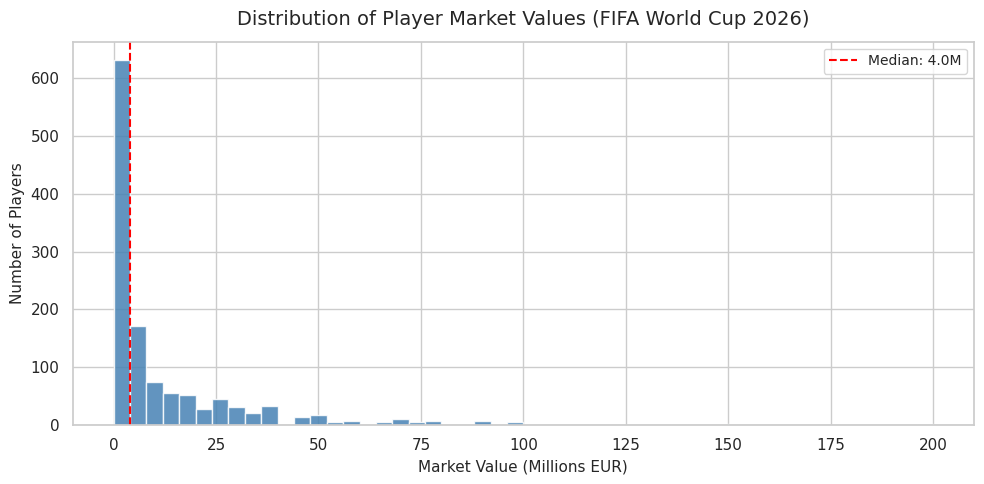

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))

# Use log scale for market values since distribution is heavily right-skewed
values_in_millions = merged['market_value_eur'] / 1_000_000
ax.hist(values_in_millions, bins=50, color='steelblue', edgecolor='white', alpha=0.85)

ax.set_title('Distribution of Player Market Values (FIFA World Cup 2026)', fontsize=14, pad=12)
ax.set_xlabel('Market Value (Millions EUR)', fontsize=11)
ax.set_ylabel('Number of Players', fontsize=11)
ax.axvline(values_in_millions.median(), color='red', linestyle='--', linewidth=1.5, label=f'Median: {values_in_millions.median():.1f}M')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

### 7.2 Bar Chart: Top 15 Teams by Average Market Value

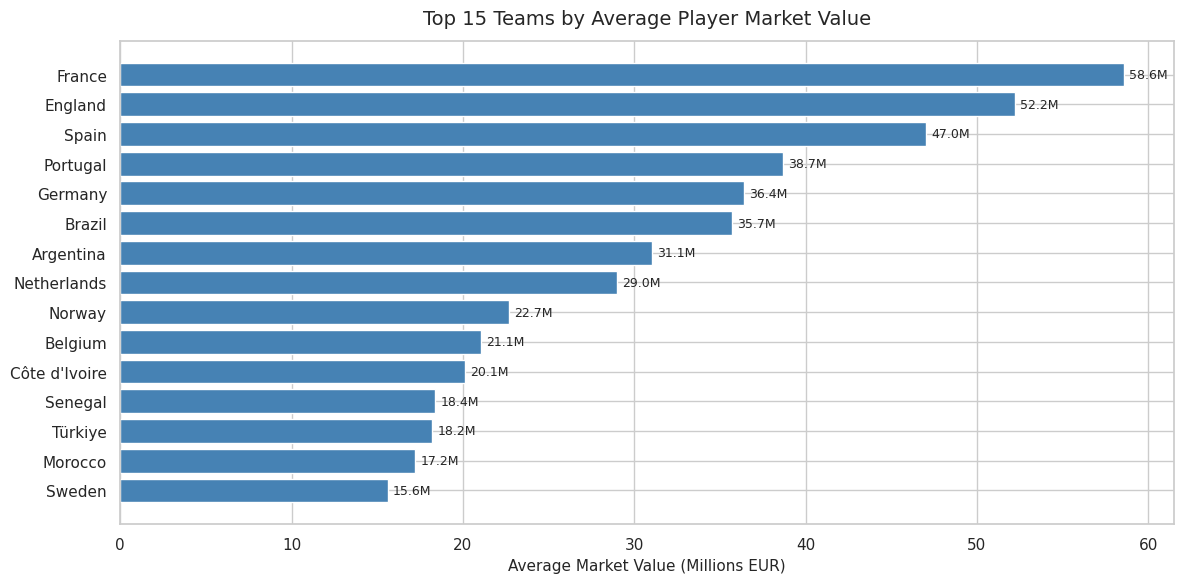

In [23]:
merged_team = pd.merge(
    merged, teams[['team_id', 'team_name']], on='team_id', how='left'
)

team_avg_value = (
    merged_team.groupby('team_name')['market_value_eur']
    .mean()
    .sort_values(ascending=False)
    .head(15)
    / 1_000_000
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(
    team_avg_value.index[::-1],
    team_avg_value.values[::-1],
    color='steelblue',
    edgecolor='white'
)

ax.set_title('Top 15 Teams by Average Player Market Value', fontsize=14, pad=12)
ax.set_xlabel('Average Market Value (Millions EUR)', fontsize=11)
ax.set_ylabel('')

# Add value labels on bars
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{width:.1f}M', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 8. Key Findings

**Data Quality:**
- The dataset was relatively well-structured with minimal true missing data.
- Most missing values in `player_stats` were by design (goalkeeper vs outfield
  field distinction).
- A few players had missing `club_team` records, filled with 'Unknown'.
- One Scottish player entry had an incomplete name ('Mc').

**Statistical Observations:**
- Player market values are heavily right-skewed, with a small number of
  elite players commanding values above 80M EUR.
- The average player height is around 182 cm.
- Forwards and midfielders make up the majority of squads.
- Traditional football powerhouses (Brazil, Argentina, France, England,
  Germany) have the highest average player market values.

**Cleaning Decisions:**
- Missing goalkeeper stats were filled with 0 (not applicable for outfield).
- `date_of_birth` was converted to datetime and age was derived.
- An `age` column was engineered for potential further analysis.